In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')

scarf.fetch_dataset('tenx_5K_pbmc_rnaseq', save_path='scarf_datasets')
reader = scarf.CrH5Reader('scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5')
scarf.CrToZarr(reader, zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr').dump(batch_size=1000)

In [2]:
ds = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr', nthreads=4, min_features_per_cell=10)
ds.filter_cells(attrs=['RNA_nCounts', 'RNA_nFeatures'], highs=[15000, 4000], lows=[1000, 500])

Minimum cell count (502) is lower than size factor multiplier (1000)



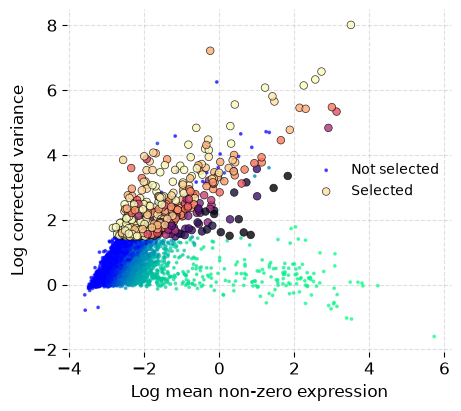

In [3]:
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

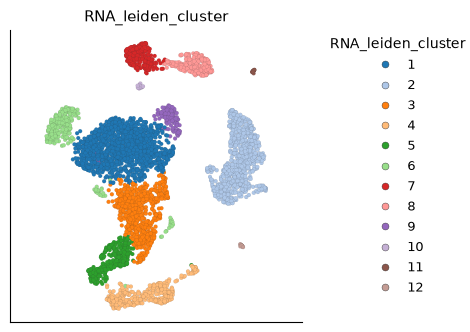

PlotResult(axes=1, tables=0, legends=1, scales=2, owns_figure=True, rendered=True)

In [4]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)